<a href="https://www.kaggle.com/code/tokarserhii/dz-2026-01-26?scriptVersionId=294807511" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:

=====================================================================================
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи
 
На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader
Створити нейромережу:
використайте 3-5 шари
перший шар Flatten
кількість нейронів у шарах має не збільшуватись
використайте функції активації RELU або LeakyRELU
Збережіть kaggle notebook для подальшої роботи
 
На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader
Створити згорткову нейромережу:
розмір фільтрів - 3
MaxPooling - kernel_size=2, stride=2
можете змінити розмір зображення в transformer до 64
Виведіть confussion matrix та основні метрики
Збережіть kaggle notebook для подальшої роботи
 

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [3]:
all_dataset = datasets.ImageFolder(data_dir)

In [4]:
all_dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [5]:
num_classes = len(all_dataset.classes)
num_classes

33

In [6]:
from torchvision import transforms

IMG_SIZE = 64  # "можете змінити до 64"

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])



In [7]:
len(all_dataset)

16854

In [8]:


data_train, data_test = torch.utils.data.random_split(all_dataset,[0.8, 0.2])


In [9]:
print(len(data_train), len(data_test), len(data_train) + len(data_test))

13484 3370 16854


In [10]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]
        new_img = self.transformer(img)
        return new_img, y

In [11]:
train_data = TransformDataset(data_train,train_transform)
test_data = TransformDataset(data_test,test_transform)
print(len(train_data), len(test_data))

13484 3370


In [12]:
train_loader = DataLoader(train_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)



In [13]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size

(64, 64, 3)


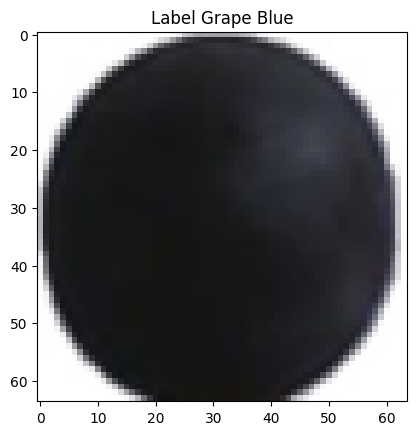

(64, 64, 3)


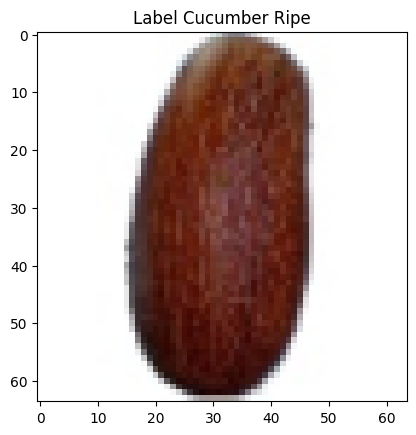

(64, 64, 3)


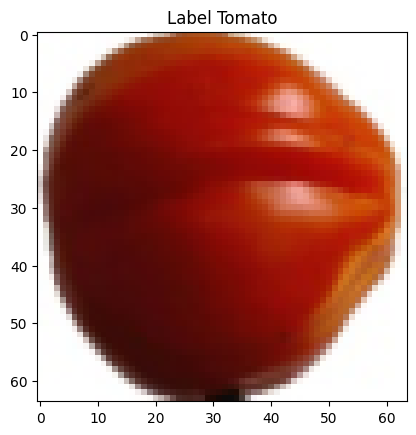

In [14]:


import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = all_dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()



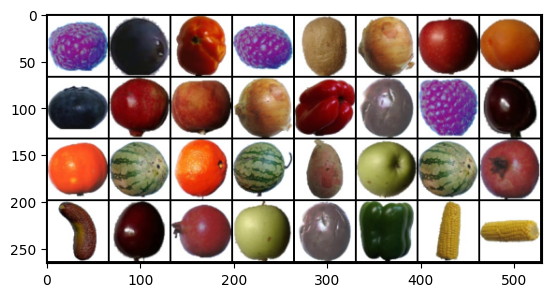

In [15]:
from torchvision.utils import make_grid
loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)
batch, labels = next(iter(loader))
grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор
plt.imshow(grid)

In [16]:
batch.shape

torch.Size([32, 3, 64, 64])

In [17]:
img, label = train_data[0]
img.shape

torch.Size([3, 64, 64])

In [18]:
for img,idx in test_loader:
    break

img.shape

torch.Size([64, 3, 64, 64])

In [19]:
device = 'cuda'
16*28*28

12544

In [22]:

import torch
import torch.nn as nn

# num_classes = len(train_dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding=1),  # filter 3x3
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),      # 2x2, stride 2

    nn.Conv2d(8, 16, kernel_size=3, padding=1), # filter 3x3
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),# filter 3x3
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.AdaptiveAvgPool2d((4,4)),
    nn.Flatten(),
    nn.Linear(32*4*4, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)                 #  33 класи
).to(device)


In [23]:
for imgs, labels in train_loader:
    break
imgs.shape

torch.Size([64, 3, 64, 64])

In [24]:
import torch
from tqdm import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (imgs, labels) in enumerate(tqdm(train_loader, leave=False)):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

    print(f"===== Epoch {epoch+1} finished. Avg train loss: {running_loss/len(train_loader):.4f}")


  1%|▏         | 3/211 [00:00<00:40,  5.11it/s]

Epoch 1/10, Batch 0/211, Loss: 3.5082


 11%|█         | 23/211 [00:02<00:15, 12.18it/s]

Epoch 1/10, Batch 20/211, Loss: 3.4970


 20%|██        | 43/211 [00:03<00:13, 12.77it/s]

...

 86%|████████▋ | 182/211 [00:13<00:02, 12.48it/s]

Epoch 10/10, Batch 180/211, Loss: 0.0077


 96%|█████████▌| 202/211 [00:15<00:00, 13.42it/s]

Epoch 10/10, Batch 200/211, Loss: 0.0008


===== Epoch 10 finished. Avg train loss: 0.0901


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)  # має бути (33, 33)
print(cm)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision (macro):", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 (macro):", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("\nReport:\n", classification_report(
    y_true, y_pred, zero_division=0
))

Confusion matrix shape: (33, 33)
[[102   0   0 ...   0   0   0]
 [  0  78   0 ...   0   0   0]
 [  0   0  98 ...   0   0   0]
 ...
 [  0   0   0 ...  98   0   0]
 [  0   0   0 ...   0 143   0]
 [  0   0   0 ...   0   0  91]]
Accuracy: 0.998813056379822
Precision (macro): 0.9988508376358842
Recall (macro): 0.9989819671622334
F1 (macro): 0.9989064501644643

Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       102
           1       1.00      1.00      1.00        78
           2       1.00      1.00      1.00        98
           3       1.00      1.00      1.00        70
           4       1.00      1.00      1.00        99
           5       1.00      1.00      1.00        95
           6       1.00      1.00      1.00       105
           7       1.00      1.00      1.00       103
           8       1.00      1.00      1.00        94
           9       1.00      1.00      1.00       107
          10       1.00      1.00     

За результатами тестування модель показала високу якість класифікації. Матриця помилок має майже всі значення на головній діагоналі, що свідчить про коректне розпізнавання класів. Основні метрики (accuracy, precision, recall, F1-score) наближаються до 1.0, що означає високу точність та стабільність моделі для всіх 33 класів.